In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from piemd import PIEMD
from base_classes import Source, DiskSource
import scipy as sp
from PIL import Image
from astropy.io import fits

ModuleNotFoundError: No module named 'base_classes'

In [ ]:
with fits.open("data/PSFEFF_WFC3UV_F814W_C0.fits") as hdul:
    data = hdul[0].data      # image array
    header = hdul[0].header  # FITS header (metadata)

CRVAL2  =-4.750158524839E+01                                                     [astropy.io.fits.card]
CTYPE1  =RA---TAN'                                                               [astropy.io.fits.card]
CTYPE2  =DEC--TAN'                                                               [astropy.io.fits.card]
DATE-OBS=2010-01-12'                                                             [astropy.io.fits.card]
TIME-OBS=19:57:55'                                                               [astropy.io.fits.card]
ROOTNAME=ibc302iqq                                                               [astropy.io.fits.card]
TARGNAME=OMEGACEN                                                                [astropy.io.fits.card]
DEC_TARG=-4.747905555556E+01                                                     [astropy.io.fits.card]


In [ ]:
fits.info("data/PSFEFF_WFC3UV_F814W_C0.fits")

data = fits.getdata("data/PSFEFF_WFC3UV_F814W_C0.fits")

Filename: data/PSFEFF_WFC3UV_F814W_C0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      35   (1401, 801)   float32   


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

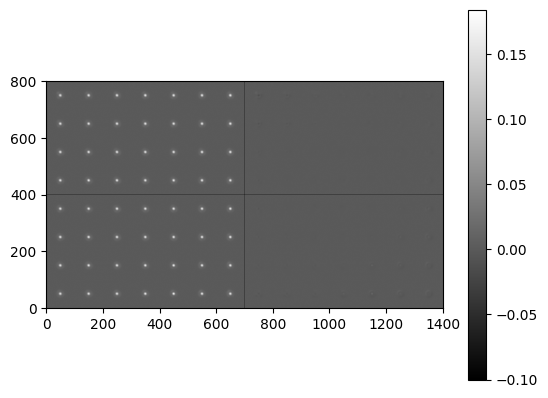

In [ ]:
plt.imshow(data, origin="lower", cmap="gray")
plt.colorbar()
plt.show()

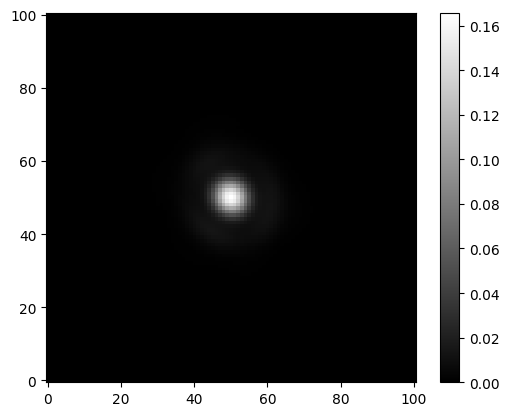

In [ ]:
cx, cy = (350,650)
dx = dy = 50
plt.imshow(data[cy-dy:cy+dy+1, cx-dx:cx+dx+1], origin="lower", cmap="gray")
plt.colorbar()
plt.show()

In [ ]:
data[cy-dy:cy+dy+1, cx-dx:cx+dx+1].shape

(101, 101)

In [ ]:
oversample = 4
psf = sp.ndimage.zoom(data[cy-dy:cy+dy+1, cx-dx:cx+dx+1], 1/oversample)

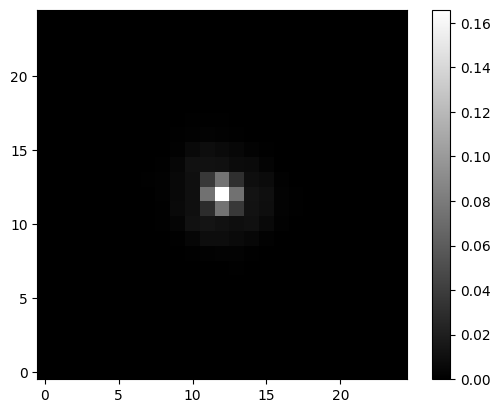

In [ ]:
plt.imshow(psf, origin="lower", cmap="gray")
plt.colorbar()
plt.show()

In [ ]:
psf /= np.sum(psf)
np.save("data/psf", psf)

In [44]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from piemd import PIEMD
# from base_classes import Source, DiskSource
import scipy as sp
from PIL import Image
from astropy.io import fits

In [45]:
with fits.open("data/EUC_VIS_GRD-PSF-000-000000-0000000__20240322T192915.424564Z.fits") as hdul:
    data = hdul[0].data      # image array
    header = hdul[0].header  # FITS header (metadata)

In [46]:
fits.info("data/EUC_VIS_GRD-PSF-000-000000-0000000__20240322T192915.424564Z.fits")

data = fits.getdata("data/EUC_VIS_GRD-PSF-000-000000-0000000__20240322T192915.424564Z.fits")

Filename: data/EUC_VIS_GRD-PSF-000-000000-0000000__20240322T192915.424564Z.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   ()      
  1  1-1.E         1 ImageHDU        19   (189, 189)   float32   
  2  1-1.F         1 ImageHDU        19   (189, 189)   float32   
  3  1-1.G         1 ImageHDU        19   (189, 189)   float32   
  4  1-1.H         1 ImageHDU        19   (189, 189)   float32   
  5  1-2.E         1 ImageHDU        19   (189, 189)   float32   
  6  1-2.F         1 ImageHDU        19   (189, 189)   float32   
  7  1-2.G         1 ImageHDU        19   (189, 189)   float32   
  8  1-2.H         1 ImageHDU        19   (189, 189)   float32   
  9  1-3.E         1 ImageHDU        19   (189, 189)   float32   
 10  1-3.F         1 ImageHDU        19   (189, 189)   float32   
 11  1-3.G         1 ImageHDU        19   (189, 189)   float32   
 12  1-3.H         1 ImageHDU        19   (189, 189)   float32   
 13  1-4.E     

In [47]:
data = data[4*21:5*21,4*21:5*21]
data /= np.sum(data)

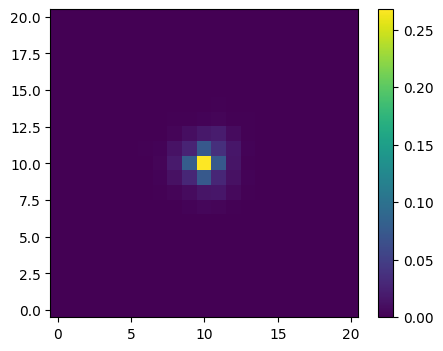

In [48]:
plt.imshow(data, origin="lower", cmap="viridis")
plt.colorbar()
plt.show()

In [49]:
data.shape

(21, 21)

In [ ]:
np.save("data/euclid_psf", data)

In [3]:

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['image.origin'] = 'lower'
matplotlib.rcParams['figure.figsize'] = (5,4)

In [4]:
import stpsf

In [5]:
nc = stpsf.NIRCam()

In [6]:
psf = nc.calc_psf(nlambda=10, fov_arcsec=2)

In [7]:
type(psf)

astropy.io.fits.hdu.hdulist.HDUList

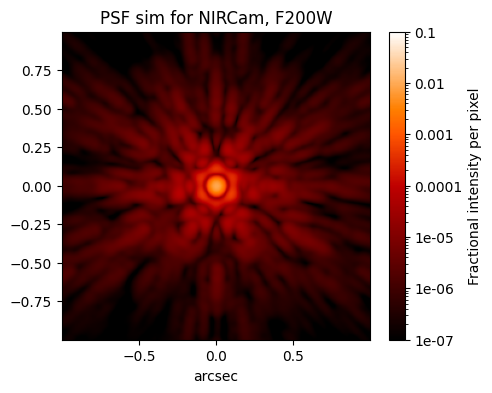

In [8]:
stpsf.display_psf(hdulist_or_filename=psf)
plt.show()

In [9]:
psf = nc.calc_psf(nlambda=20, fov_arcsec=2)

In [25]:
import scipy as sp
import numpy as np

In [37]:
data = psf[0].data        # numpy array

data_zoomed = sp.ndimage.zoom(data, 0.847)
np.array(data_zoomed).shape

(217, 217)

In [38]:
np.save("data/JWST_psf.npy", data_zoomed)

In [16]:
np.array(data).shape

(230, 230)

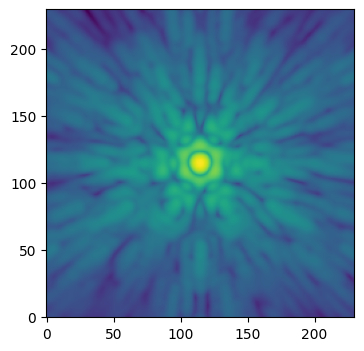

In [17]:
plt.imshow(data, norm='log')
plt.show()